In [11]:
%pip install matplotlib tqdm

Note: you may need to restart the kernel to use updated packages.


In [13]:
import chipwhisperer as cw # You only can use the basic ChipWhisperer functions demonstrated in this basic code
import numpy as np
import random
from tqdm.notebook import trange
import struct


# Also the ChipWhisperer provides better plotting functions (based on matplotlib), choose what you prefer
import matplotlib.pyplot as plt

# Initialize ChipWhisperer components
scope = cw.scope()
target = cw.target(scope, cw.targets.SimpleSerial)
scope.default_setup()

# we got 724, so we set it to be a little higher than that(because it depends on the id) 
scope.adc.samples=1500

scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 1147543                   to 23305051                 
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 0                         to 29538459                 
scope.clock.adc_rate                     changed from 0.0                       to 29538459.0               
scope.clock.clkgen_

In [14]:
%%bash
make PLATFORM=CWLITEARM SOURCE=c_code.c

No CRYPTO_TARGET passed - defaulting to TINYAES128C
Building for platform CWLITEARM with CRYPTO_TARGET=TINYAES128C
SS_VER set to SS_VER_1_1
SS_VER set to SS_VER_1_1
Blank crypto options, building for AES128


.
Welcome to another exciting ChipWhisperer target build!!
arm-none-eabi-gcc (Arm GNU Toolchain 15.2.Rel1 (Build arm-15.86)) 15.2.1 20251203
Copyright (C) 2025 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

mkdir -p objdir-CWLITEARM 
.
Compiling:
-en     c_code.c ...
-e Done!
.
Compiling:
-en     ../../firmware/mcu/simpleserial/simpleserial.c ...
-e Done!
.
Compiling:
-en     ../../firmware/mcu/hal//stm32f3/stm32f3_hal.c ...
-e Done!
.
Compiling:
-en     ../../firmware/mcu/hal//stm32f3/stm32f3_hal_lowlevel.c ...
-e Done!
.
Compiling:
-en     ../../firmware/mcu/hal//stm32f3/stm32f3_sysmem.c ...
-e Done!
.
Compiling:
-en     ../../firmware/mcu/crypto/tiny-AES128-C/aes.c ...
-e Done!
.
Compiling:
-en     ../../firmware/mcu/crypto/aes-independant.c ...
-e Done!
.
Assembling: ../../firmware/mcu/hal//stm32f3/stm32f3_startup.S
arm-none-eabi-gcc -c -mcpu=corte

/Applications/ArmGNUToolchain/15.2.rel1/arm-none-eabi/bin/../lib/gcc/arm-none-eabi/15.2.1/../../../../arm-none-eabi/bin/ld: /Applications/ArmGNUToolchain/15.2.rel1/arm-none-eabi/bin/../lib/gcc/arm-none-eabi/15.2.1/../../../../arm-none-eabi/lib/thumb/v7e-m/nofp/libg_nano.a(libc_a-closer.o): in function `_close_r':
closer.c:(.text._close_r+0xc): warning: _close is not implemented and will always fail


/Applications/ArmGNUToolchain/15.2.rel1/arm-none-eabi/bin/../lib/gcc/arm-none-eabi/15.2.1/../../../../arm-none-eabi/bin/ld: /Applications/ArmGNUToolchain/15.2.rel1/arm-none-eabi/bin/../lib/gcc/arm-none-eabi/15.2.1/../../../../arm-none-eabi/lib/thumb/v7e-m/nofp/libg_nano.a(libc_a-closer.o): note: the message above does not take linker garbage collection into account
/Applications/ArmGNUToolchain/15.2.rel1/arm-none-eabi/bin/../lib/gcc/arm-none-eabi/15.2.1/../../../../arm-none-eabi/bin/ld: /Applications/ArmGNUToolchain/15.2.rel1/arm-none-eabi/bin/../lib/gcc/arm-none-eabi/15.2.1/../../../../arm-none-eabi/lib/thumb/v7e-m/nofp/libg_nano.a(libc_a-lseekr.o): note: the message above does not take linker garbage collection into account
/Applications/ArmGNUToolchain/15.2.rel1/arm-none-eabi/bin/../lib/gcc/arm-none-eabi/15.2.1/../../../../arm-none-eabi/bin/ld: /Applications/ArmGNUToolchain/15.2.rel1/arm-none-eabi/bin/../lib/gcc/arm-none-eabi/15.2.1/../../../../arm-none-eabi/lib/thumb/v7e-m/nofp/lib

/Applications/ArmGNUToolchain/15.2.rel1/arm-none-eabi/bin/../lib/gcc/arm-none-eabi/15.2.1/../../../../arm-none-eabi/bin/ld: /Applications/ArmGNUToolchain/15.2.rel1/arm-none-eabi/bin/../lib/gcc/arm-none-eabi/15.2.1/../../../../arm-none-eabi/lib/thumb/v7e-m/nofp/libg_nano.a(libc_a-lseekr.o): in function `_lseek_r':
lseekr.c:(.text._lseek_r+0x10): warning: _lseek is not implemented and will always fail
/Applications/ArmGNUToolchain/15.2.rel1/arm-none-eabi/bin/../lib/gcc/arm-none-eabi/15.2.1/../../../../arm-none-eabi/bin/ld: /Applications/ArmGNUToolchain/15.2.rel1/arm-none-eabi/bin/../lib/gcc/arm-none-eabi/15.2.1/../../../../arm-none-eabi/lib/thumb/v7e-m/nofp/libg_nano.a(libc_a-readr.o): in function `_read_r':
readr.c:(.text._read_r+0x10): warning: _read is not implemented and will always fail
/Applications/ArmGNUToolchain/15.2.rel1/arm-none-eabi/bin/../lib/gcc/arm-none-eabi/15.2.1/../../../../arm-none-eabi/bin/ld: /Applications/ArmGNUToolchain/15.2.rel1/arm-none-eabi/bin/../lib/gcc/arm-no

/Applications/ArmGNUToolchain/15.2.rel1/arm-none-eabi/bin/../lib/gcc/arm-none-eabi/15.2.1/../../../../arm-none-eabi/bin/ld: /Applications/ArmGNUToolchain/15.2.rel1/arm-none-eabi/bin/../lib/gcc/arm-none-eabi/15.2.1/../../../../arm-none-eabi/lib/thumb/v7e-m/nofp/libg_nano.a(libc_a-writer.o): note: the message above does not take linker garbage collection into account


/Applications/ArmGNUToolchain/15.2.rel1/arm-none-eabi/bin/../lib/gcc/arm-none-eabi/15.2.1/../../../../arm-none-eabi/bin/ld: warning: output-CWLITEARM.elf has a LOAD segment with RWX permissions


-e Done!
.
Creating load file for Flash: output-CWLITEARM.hex
arm-none-eabi-objcopy -O ihex -R .eeprom -R .fuse -R .lock -R .signature output-CWLITEARM.elf output-CWLITEARM.hex
.
Creating load file for Flash: output-CWLITEARM.bin
arm-none-eabi-objcopy -O binary -R .eeprom -R .fuse -R .lock -R .signature output-CWLITEARM.elf output-CWLITEARM.bin
.
Creating load file for EEPROM: output-CWLITEARM.eep
arm-none-eabi-objcopy -j .eeprom --set-section-flags=.eeprom="alloc,load" \
	--change-section-lma .eeprom=0 --no-change-warnings -O ihex output-CWLITEARM.elf output-CWLITEARM.eep || exit 0
.
Creating Extended Listing: output-CWLITEARM.lss
arm-none-eabi-objdump -h -S -z output-CWLITEARM.elf > output-CWLITEARM.lss
.
Creating Symbol Table: output-CWLITEARM.sym
arm-none-eabi-nm -n output-CWLITEARM.elf > output-CWLITEARM.sym
Size after:
   text	   data	    bss	    dec	    hex	filename
   5712	      8	   1472	   7192	   1c18	output-CWLITEARM.elf
+----------------------------------------------------

In [15]:
hex = "output-CWLITEARM.hex"
cw.program_target(scope, cw.programmers.STM32FProgrammer , hex)

Detected known STMF32: STM32F302xB(C)/303xB(C)
Extended erase (0x44), this can take ten seconds or more
Attempting to program 5719 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 5719 bytes


In [16]:
def execute_trace(command, input_string):
    # Clears any leftover data and arms the scope
    scope.arm()

    # Convert input to bytearray
    if isinstance(input_string, str):
        input_data = bytearray(input_string, 'utf-8')
    else:
        input_data = bytearray(input_string)
        
    # Send the command
    target.simpleserial_write(command, input_data)

    # Capture the trace
    ret = scope.capture()
    if ret:
        raise Exception("Failed to capture trace")

    # Get the trace data
    trace = scope.get_last_trace()
    
    # READ RAW BYTES (Remove the .decode('utf-8'))
    response = target.simpleserial_read('r', 1)
    
    return trace, response

In [22]:
FLAG_HIGH_HW = 1 << 0
FLAG_MASKED = 1 << 1
FLAG_SHUFFLED = 1 << 2

def build_mode_flags(is_high_hw=False, is_masked=False, is_shuffled=False):
    flags = 0
    if is_high_hw:
        flags |= FLAG_HIGH_HW
    if is_masked:
        flags |= FLAG_MASKED
    if is_shuffled:
        flags |= FLAG_SHUFFLED
    return flags

def set_mode_flags(is_high_hw=False, is_masked=False, is_shuffled=False):
    """Set mode flags on target using command 'f'."""
    flags = build_mode_flags(is_high_hw, is_masked, is_shuffled)
    target.simpleserial_write('f', bytearray([flags]))
    response = target.simpleserial_read('r', 1, timeout=100)
    return response


def set_seed(seed_value, is_high_hw=False, is_masked=False, is_shuffled=False, mask_value=0, mask_value2=0, apply_flags=True):
    """
    Sends a 32-bit seed to the unified seed command 's'.
    Payload is 16 bytes: [state(4B), mask1(4B), mask2(4B), shuffle_rng(4B)].
    """
    if apply_flags:
        set_mode_flags(is_high_hw=is_high_hw, is_masked=is_masked, is_shuffled=is_shuffled)

    state32 = int(seed_value) & 0xFFFFFFFF
    
    # Generate Masks
    mask1_32 = (int(mask_value) & 0xFFFFFFFF) if is_masked else 0
    mask2_32 = (int(mask_value2) & 0xFFFFFFFF) if is_masked else 0
    
    # Generate Random Shuffle Initializer
    shuffle_val_32 = 0
    if is_masked and is_shuffled:
        shuffle_val_32 = int(np.random.randint(0, 0xFFFFFFFF, dtype=np.uint32))
        
    payload = struct.pack('<IIII', state32, mask1_32, mask2_32, shuffle_val_32)

    target.simpleserial_write('s', bytearray(payload))
    response = target.simpleserial_read('r', 1, timeout=100)
    return response


In [23]:
# --- Advanced Functional Verification ---
print("\nVerifying LFSR Logic with Interesting Seeds...")

# Keep the mode explicit for this check: Low-HW, unmasked, non-shuffled
set_mode_flags(is_high_hw=False, is_masked=False, is_shuffled=False)

# Test Case A: Seed where result LSB should be 0x01
seed_a = 0x00000003
print(f"Testing Seed: 0x{seed_a:08x}")
set_seed(seed_a, is_high_hw=False, is_masked=False, is_shuffled=False, apply_flags=False)
_, resp_a = execute_trace('c', [1])
val_a = ord(resp_a[0]) if isinstance(resp_a, str) else resp_a[0]
print(f"Result LSB: 0x{val_a:02x} (Expected: 0x01)")

# Test Case B: Seed with High Bit
seed_b = 0x80000001
print(f"\nTesting Seed: 0x{seed_b:08x}")
set_seed(seed_b, is_high_hw=False, is_masked=False, is_shuffled=False, apply_flags=False)
_, resp_b = execute_trace('c', [1])
val_b = ord(resp_b[0]) if isinstance(resp_b, str) else resp_b[0]
print(f"Result LSB: 0x{val_b:02x} (Expected: 0x00)")

# Check if both passed
if val_a == 0x01 and val_b == 0x00:
    print("\nPROVEN: LFSR Logic is 100% Correct and Active!")
else:
    print("\nLOGIC ERROR: Results do not match expected LFSR behavior.")

(ChipWhisperer Target WARNING|File SimpleSerial.py:447) Unexpected start to command: 



Verifying LFSR Logic with Interesting Seeds...
Testing Seed: 0x00000003
Result LSB: 0x27 (Expected: 0x01)

Testing Seed: 0x80000001


(ChipWhisperer Target WARNING|File SimpleSerial.py:447) Unexpected start to command: 


Result LSB: 0x93 (Expected: 0x00)

LOGIC ERROR: Results do not match expected LFSR behavior.


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from tqdm import trange

def run_lfsr_ttest(is_high_hw=False, num_traces=5000, num_steps=1, is_masked=False, is_shuffled=False, mask_seed=0xA5A5A5A5):
    """
    Performs a full Welch's T-Test experiment for a specific LFSR mode.

    Args:
        is_high_hw (bool): True for High HW polynomial, False for Low HW.
        num_traces (int): Number of traces to collect.
        num_steps (int): Number of LFSR steps to perform per trace.
        is_masked (bool): Enable masked processing path.
        is_shuffled (bool): Enable shuffled step implementation path.
        mask_seed (int): 32-bit mask value used when is_masked=True.
    """

    mode_flags_resp = set_mode_flags(
        is_high_hw=is_high_hw,
        is_masked=is_masked,
        is_shuffled=is_shuffled
    )
    mode_flags_val = mode_flags_resp[0] if not isinstance(mode_flags_resp, str) else ord(mode_flags_resp[0])

    step_cmd = 'c'
    label = "High HW" if is_high_hw else "Low HW"
    label += ", Masked" if is_masked else ", Unmasked"
    label += ", Shuffled" if is_shuffled else ", Non-Shuffled"
    fixed_seed = 0x12345678
    print(f"Fixed Seed: {fixed_seed:08x}")
    print(f"Mode Flags Sent: 0x{mode_flags_val:02x}")

    traces = []
    groups = []  # 0: Fixed, 1: Random

    print(f"--- Starting Leakage Assessment for {label} ({num_steps} steps) ---")

    for i in trange(num_traces, desc="Capturing"):
        is_random = np.random.randint(0, 2)

        if is_random:
            current_seed = np.random.randint(0, 0xFFFFFFFF, dtype=np.uint32)
            groups.append(1)
        else:
            current_seed = fixed_seed
            groups.append(0)

        set_seed(
            current_seed,
            is_high_hw=is_high_hw,
            is_masked=is_masked,
            is_shuffled=is_shuffled,
            mask_value=mask_seed,
            mask_value2=np.random.randint(0, 0xFFFFFFFF, dtype=np.uint32),  # NEW: second random mask
            apply_flags=False
        )

        trace, _ = execute_trace(step_cmd, [num_steps])
        traces.append(trace)

    traces = np.array(traces)
    groups = np.array(groups)

    print("Calculating T-test statistics...")
    group_fixed = traces[groups == 0]
    group_random = traces[groups == 1]

    t_values = stats.ttest_ind(group_fixed, group_random, axis=0, equal_var=False)[0]

    plt.figure(figsize=(12, 6))
    plt.plot(t_values, label=f"T-test ({label}, {num_steps} steps)", color='tab:blue', linewidth=1.5)

    plt.axhline(y=4.5, color='crimson', linestyle='--', label='Threshold ±4.5')
    plt.axhline(y=-4.5, color='crimson', linestyle='--')

    plt.title(f"Welch's T-Test: {label} (N={num_traces}, Steps={num_steps})")
    plt.xlabel("Sample Index")
    plt.ylabel("T-Statistic")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right')

    y_abs_max = max(np.max(np.abs(t_values)), 6.0)
    plt.ylim(-y_abs_max, y_abs_max)

    plt.tight_layout()
    plt.show()

    max_t = np.max(np.abs(t_values))
    print(f"Experiment Finished. Max Absolute T-Value: {max_t:.4f}")
    if max_t > 4.5:
        print("RESULT: LEAKAGE DETECTED (t-value exceeds 4.5 threshold)")
    else:
        print("RESULT: NO LEAKAGE DETECTED (t-value within 4.5 threshold)")

Fixed Seed: 12345678
Mode Flags Sent: 0x02
--- Starting Leakage Assessment for Low HW, Masked, Non-Shuffled (20 steps) ---


Capturing:   0%|          | 0/5000 [00:00<?, ?it/s]

Capturing: 100%|██████████| 5000/5000 [01:37<00:00, 51.14it/s]


Calculating T-test statistics...


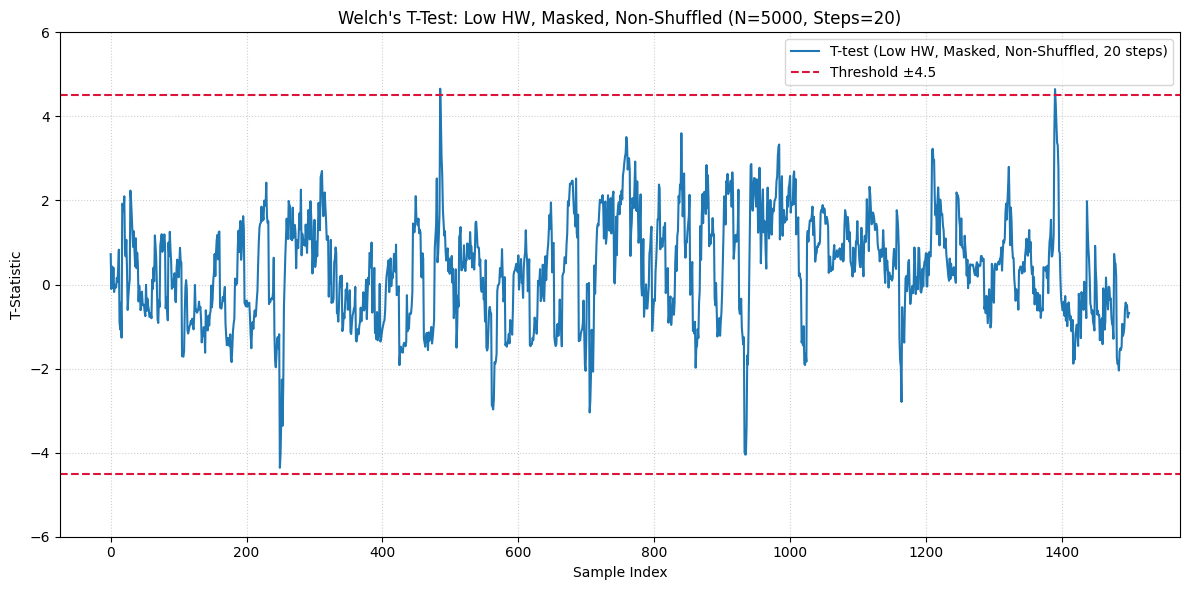

Experiment Finished. Max Absolute T-Value: 4.6585
RESULT: LEAKAGE DETECTED (t-value exceeds 4.5 threshold)


In [ ]:
# Executing T-test for Low Hamming Weight LFSR (Polynomial HW=5)
# Parameters: is_high_hw=False, num_traces=5000
run_lfsr_ttest(is_high_hw=False, num_traces=5000, num_steps=20, is_masked=True, is_shuffled=True)

Fixed Seed: 12345678
Mode Flags Sent: 0x00
--- Starting Leakage Assessment for Low HW, Unmasked, Non-Shuffled (20 steps) ---


Capturing:   0%|          | 0/5000 [00:00<?, ?it/s]

Capturing: 100%|██████████| 5000/5000 [01:37<00:00, 51.03it/s]


Calculating T-test statistics...


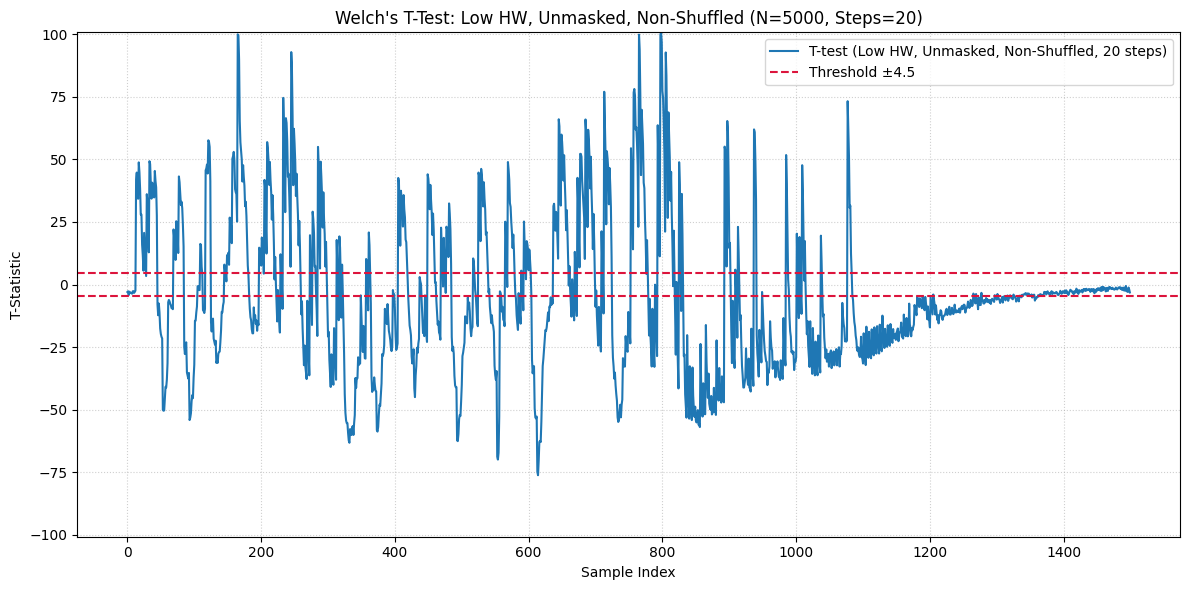

Experiment Finished. Max Absolute T-Value: 100.8305
RESULT: LEAKAGE DETECTED (t-value exceeds 4.5 threshold)


In [21]:
# Executing T-test for High Hamming Weight LFSR (Polynomial HW=15)
# Parameters: is_high_hw=True, num_traces=5000
run_lfsr_ttest(is_high_hw=False, num_traces=5000, num_steps=20)

In [ ]:
counts = []
for i in range(10):
    scope.arm()
    target.simpleserial_write('c', bytearray([1]))
    scope.capture()
    counts.append(scope.adc.trig_count)

print(f"Trig counts: {counts}")
print(f"Min: {min(counts)}, Max: {max(counts)}")

In [ ]:
# Disconnect ChipWhisperer components - very important to avoid simpleserial issues
scope.dis()
target.dis()